# Module 8 — Rule Comprehension Analysis

**Research Question**: Do LLMs truly understand the rules of the Prisoner's Dilemma they are playing?

**Checks**: Payoff matrix comprehension, score bounds, allowed actions — tested at rounds 10, 20, 30.

**Outputs**: Figure 8a (rule accuracy heatmap), Figure 8b (question-type breakdown), Figure 8c (payoff understanding by language), Figure 8d (own-vs-opponent perspective gap)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ── Publication-quality settings ──
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False,
})

# ── Color palette (color-blind friendly) ──
MODEL_COLORS = {
    'gpt-oss-20b': '#E69F00',
    'Mistral-7B-Instruct-v0.3': '#56B4E9',
    'Qwen2.5-32B-Instruct': '#009E73'
}
MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
MODEL_ORDER = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
NOISE_LABELS = {0: 'No Noise', 5: '5% Noise', 20: '20% Noise'}
NOISE_ORDER = ['No Noise', '5% Noise', '20% Noise']
LANG_LABELS = {'en': 'English', 'fr': 'French', 'ar': 'Arabic',
               'cn': 'Chinese', 'vn': 'Vietnamese', 'it': 'Italian'}
LANG_ORDER = ['English', 'French', 'Arabic', 'Chinese', 'Vietnamese', 'Italian']

FIGURE_DIR = 'figures/'
import os
os.makedirs(FIGURE_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [12]:
# ── Load rule_checker data from JSON files ──
import json

BASE_DIR = '../resources/results/Prisoner_dilemma_2player'
NOISE_MAP = {'noise00': 0, 'noise05': 5, 'noise20': 20}
CHECKER_NAME = 'rule_checker'

records = []
for model_dir in sorted(os.listdir(BASE_DIR)):
    model_path = os.path.join(BASE_DIR, model_dir)
    if not os.path.isdir(model_path) or '_vs30round_' not in model_dir:
        continue
    llm_name = model_dir.split('_vs30round_')[0]

    for noise_dir in sorted(os.listdir(model_path)):
        noise_path = os.path.join(model_path, noise_dir)
        if not os.path.isdir(noise_path) or noise_dir not in NOISE_MAP:
            continue
        noise_level = NOISE_MAP[noise_dir]

        checker_path = os.path.join(noise_path, CHECKER_NAME)
        ca_path = os.path.join(checker_path, 'complete_answers')
        if not os.path.exists(ca_path):
            continue

        for ca_file in sorted(os.listdir(ca_path)):
            if not ca_file.endswith('.json'):
                continue
            game_id = ca_file.replace('.json', '')

            # Summary file has checker name prefix instead of 'complete_answers'
            summary_fname = ca_file.replace('complete_answers_', f'{CHECKER_NAME}_')
            summary_file = os.path.join(checker_path, summary_fname)
            language = 'en'
            p1_personality = p2_personality = 'unknown'
            if os.path.exists(summary_file):
                with open(summary_file, 'r', encoding='utf-8') as fh:
                    summary = json.load(fh)
                meta = summary.get('metadata', {})
                language = meta.get('language', 'en')
                agents = meta.get('agents', {})
                p1_personality = agents.get('agent1', {}).get('personality', 'unknown')
                p2_personality = agents.get('agent2', {}).get('personality', 'unknown')

            # Read complete_answers JSON for per-round individual answers
            with open(os.path.join(ca_path, ca_file), 'r', encoding='utf-8') as fh:
                answers = json.load(fh)

            for question_label, rounds_data in answers.items():
                for round_idx, rinfo in rounds_data.items():
                    ans = rinfo['answer']
                    records.append({
                        'game_id': game_id,
                        'llm_name': llm_name,
                        'noise_level': noise_level,
                        'language': language,
                        'p1_personality': p1_personality,
                        'p2_personality': p2_personality,
                        'question_label': question_label,
                        'question_text': rinfo.get('question', ''),
                        'agent_name': ans.get('agent_name', ''),
                        'round_number': ans.get('round_number', int(round_idx)),
                        'llm_answer': ans.get('llm_answer', ''),
                        'correct_answer': ans.get('correct_answer', ''),
                        'is_correct': ans.get('is_correct', False),
                    })

df = pd.DataFrame(records)

# ── Add label columns ──
df['lang_label'] = df['language'].map(LANG_LABELS)
df['model'] = df['llm_name'].map(MODEL_LABELS)
df['noise_label'] = df['noise_level'].map(NOISE_LABELS)

# ── Classify question types ──
def classify_rule_question(label):
    if label in ('max_bound', 'min_bound'):
        return 'Score Bounds'
    elif label == 'allowed_actions':
        return 'Allowed Actions'
    elif '_p0_' in label:
        return 'Own Payoff'
    elif '_p1_' in label:
        return 'Opponent Payoff'
    else:
        return 'Other'

df['question_type'] = df['question_label'].apply(classify_rule_question)

print(f'Rule checker data loaded from JSON: {len(df):,} rows')
print(f'Models: {sorted(df["model"].unique())}')
print(f'Languages: {sorted(df["language"].unique())}')
print(f'Noise levels: {sorted(df["noise_level"].unique())}')
print(f'Question types: {sorted(df["question_type"].unique())}')
print(f'\nOverall rule accuracy: {df["is_correct"].mean():.3f}')

Rule checker data loaded from JSON: 79,920 rows
Models: ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
Languages: ['ar', 'cn', 'en', 'fr', 'it', 'vn']
Noise levels: [np.int64(0), np.int64(5), np.int64(20)]
Question types: ['Allowed Actions', 'Opponent Payoff', 'Own Payoff', 'Score Bounds']

Overall rule accuracy: 0.894


## Figure 8a — Rule Comprehension Heatmap (Model × Noise)

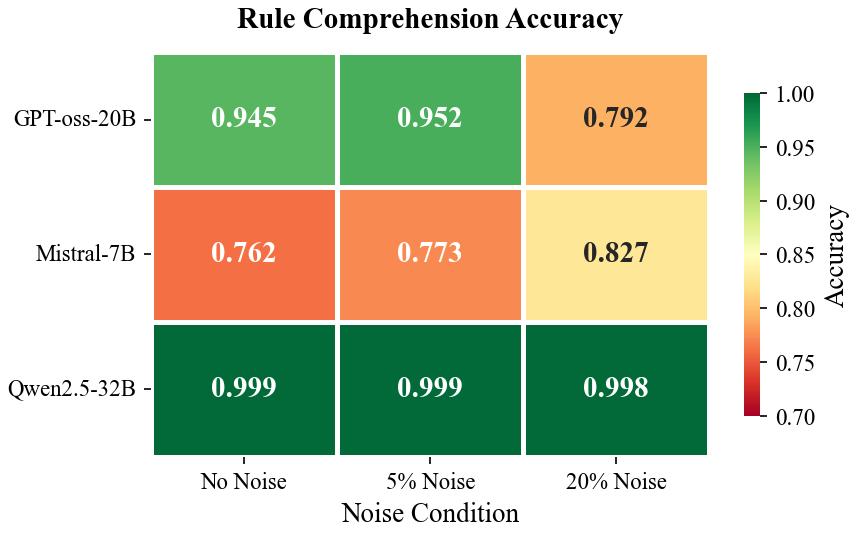


Accuracy table:
noise_label  No Noise  5% Noise  20% Noise
model                                     
GPT-oss-20B     0.945     0.952      0.792
Mistral-7B      0.762     0.773      0.827
Qwen2.5-32B     0.999     0.999      0.998


In [13]:
# ── Figure 8a: Heatmap of rule accuracy by Model × Noise ──
pivot = df.groupby(['model', 'noise_label'])['is_correct'].mean().unstack()
pivot = pivot.reindex(index=MODEL_ORDER, columns=NOISE_ORDER)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.7, vmax=1.0,
            linewidths=1.5, linecolor='white', cbar_kws={'label': 'Accuracy', 'shrink': 0.8},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'}, ax=ax)
ax.set_title('Rule Comprehension Accuracy', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Noise Condition', fontsize=13)
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.savefig(f'{FIGURE_DIR}fig8a_rule_accuracy_heatmap.pdf')
plt.savefig(f'{FIGURE_DIR}fig8a_rule_accuracy_heatmap.png')
plt.show()
print('\nAccuracy table:')
print(pivot.round(3))

## Figure 8b — Question-Type Breakdown by Model

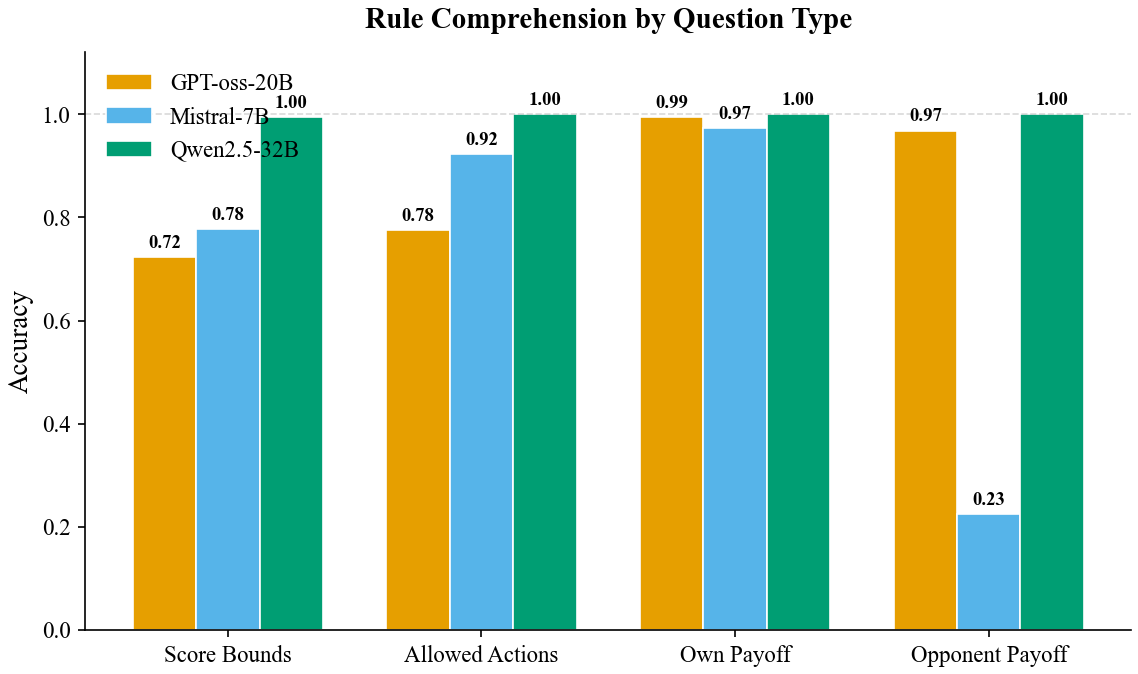


Accuracy by question type:
question_type  Score Bounds  Allowed Actions  Own Payoff  Opponent Payoff
model                                                                    
GPT-oss-20B           0.724            0.775       0.994            0.969
Mistral-7B            0.778            0.924       0.973            0.225
Qwen2.5-32B           0.995            1.000       1.000            1.000


In [14]:
# ── Figure 8b: Grouped bar chart — accuracy by question type per model ──
q_types = ['Score Bounds', 'Allowed Actions', 'Own Payoff', 'Opponent Payoff']
qt_acc = df.groupby(['model', 'question_type'])['is_correct'].mean().unstack()
qt_acc = qt_acc.reindex(index=MODEL_ORDER, columns=q_types)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(q_types))
width = 0.25
colors_list = [MODEL_COLORS[k] for k in ['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct']]

for i, model in enumerate(MODEL_ORDER):
    vals = qt_acc.loc[model].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=model, color=colors_list[i],
                  edgecolor='white', linewidth=0.8)
    # Add value labels
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Rule Comprehension by Question Type', fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(q_types, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(frameon=False, loc='upper left')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

plt.savefig(f'{FIGURE_DIR}fig8b_rule_question_type_breakdown.pdf')
plt.savefig(f'{FIGURE_DIR}fig8b_rule_question_type_breakdown.png')
plt.show()

print('\nAccuracy by question type:')
print(qt_acc.round(3))

## Figure 8c — Rule Accuracy by Language (Faceted by Model)

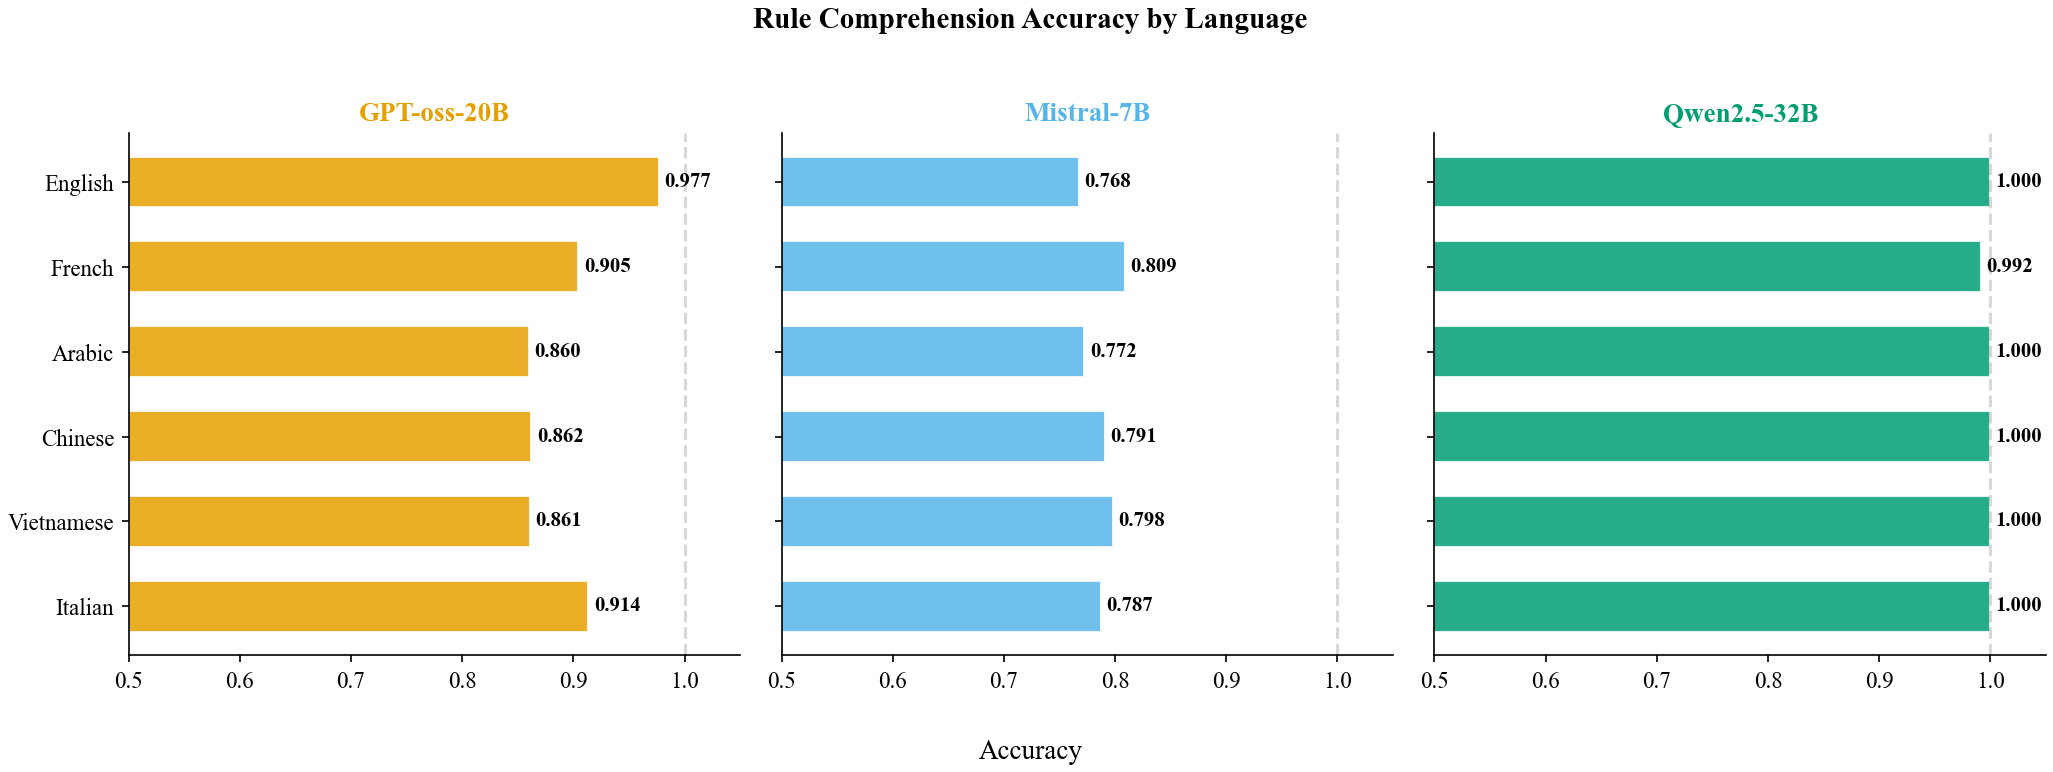

In [15]:
# ── Figure 8c: Faceted bar chart — accuracy by language for each model ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

model_keys = ['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct']

for idx, (mkey, mname) in enumerate(zip(model_keys, MODEL_ORDER)):
    ax = axes[idx]
    sub = df[df['llm_name'] == mkey]
    lang_acc = sub.groupby('lang_label')['is_correct'].mean().reindex(LANG_ORDER)
    
    bars = ax.barh(LANG_ORDER, lang_acc.values, color=MODEL_COLORS[mkey],
                   edgecolor='white', height=0.6, alpha=0.85)
    
    # Add value labels
    for bar, val in zip(bars, lang_acc.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.set_title(mname, fontsize=13, fontweight='bold', color=MODEL_COLORS[mkey])
    ax.set_xlim(0.5, 1.05)
    ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.3)
    if idx == 0:
        ax.set_ylabel('')
    ax.invert_yaxis()

fig.suptitle('Rule Comprehension Accuracy by Language', fontsize=14, fontweight='bold', y=1.02)
fig.supxlabel('Accuracy', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig8c_rule_accuracy_by_language.pdf')
plt.savefig(f'{FIGURE_DIR}fig8c_rule_accuracy_by_language.png')
plt.show()

## Figure 8d — Own vs. Opponent Payoff Understanding (Perspective Gap)

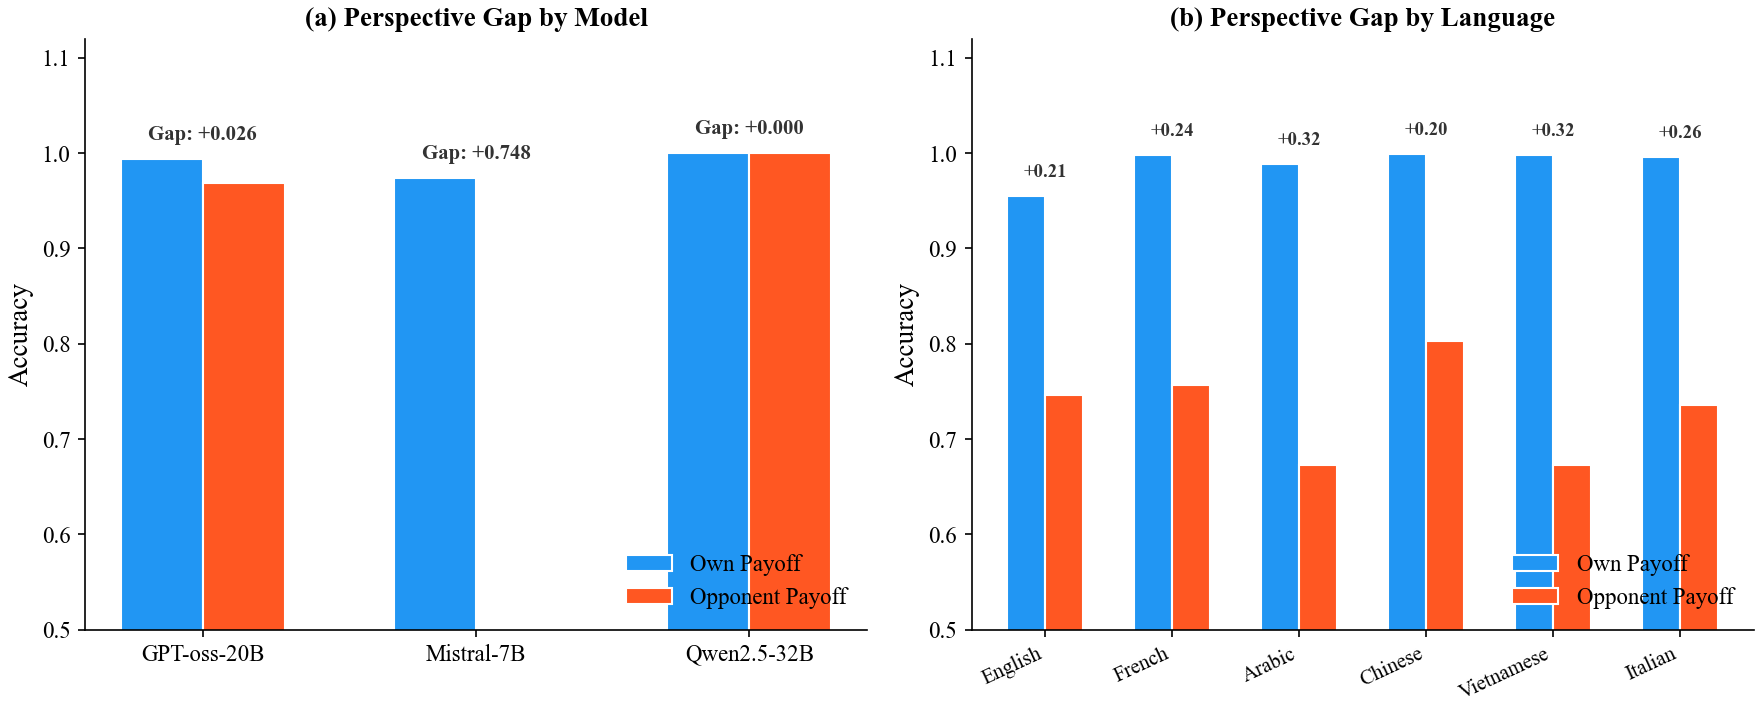


Own vs Opponent payoff accuracy by model:
question_type  Opponent Payoff  Own Payoff
model                                     
GPT-oss-20B              0.969       0.994
Mistral-7B               0.225       0.973
Qwen2.5-32B              1.000       1.000


In [16]:
# ── Figure 8d: Own vs Opponent perspective — the "Theory of Mind" gap ──
# p0 = own payoff understanding, p1 = opponent payoff understanding
perspective_df = df[df['question_type'].isin(['Own Payoff', 'Opponent Payoff'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: By Model
ax = axes[0]
persp_model = perspective_df.groupby(['model', 'question_type'])['is_correct'].mean().unstack()
persp_model = persp_model.reindex(MODEL_ORDER)

x = np.arange(len(MODEL_ORDER))
width = 0.3
ax.bar(x - width/2, persp_model['Own Payoff'], width, label='Own Payoff',
       color='#2196F3', edgecolor='white')
ax.bar(x + width/2, persp_model['Opponent Payoff'], width, label='Opponent Payoff',
       color='#FF5722', edgecolor='white')

# Add gap annotations
for i, model in enumerate(MODEL_ORDER):
    own_val = persp_model.loc[model, 'Own Payoff']
    opp_val = persp_model.loc[model, 'Opponent Payoff']
    gap = own_val - opp_val
    ax.annotate(f'Gap: {gap:+.3f}', xy=(i, max(own_val, opp_val) + 0.02),
                ha='center', fontsize=10, fontweight='bold', color='#333')

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=11)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_ylim(0.5, 1.12)
ax.set_title('(a) Perspective Gap by Model', fontsize=13, fontweight='bold')
ax.legend(frameon=False, loc='lower right')

# Panel B: By Language
ax = axes[1]
persp_lang = perspective_df.groupby(['lang_label', 'question_type'])['is_correct'].mean().unstack()
persp_lang = persp_lang.reindex(LANG_ORDER)

x = np.arange(len(LANG_ORDER))
ax.bar(x - width/2, persp_lang['Own Payoff'], width, label='Own Payoff',
       color='#2196F3', edgecolor='white')
ax.bar(x + width/2, persp_lang['Opponent Payoff'], width, label='Opponent Payoff',
       color='#FF5722', edgecolor='white')

for i, lang in enumerate(LANG_ORDER):
    own_val = persp_lang.loc[lang, 'Own Payoff']
    opp_val = persp_lang.loc[lang, 'Opponent Payoff']
    gap = own_val - opp_val
    ax.annotate(f'{gap:+.2f}', xy=(i, max(own_val, opp_val) + 0.02),
                ha='center', fontsize=9, fontweight='bold', color='#333')

ax.set_xticks(x)
ax.set_xticklabels(LANG_ORDER, fontsize=10, rotation=25, ha='right')
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_ylim(0.5, 1.12)
ax.set_title('(b) Perspective Gap by Language', fontsize=13, fontweight='bold')
ax.legend(frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig8d_perspective_gap.pdf')
plt.savefig(f'{FIGURE_DIR}fig8d_perspective_gap.png')
plt.show()

print('\nOwn vs Opponent payoff accuracy by model:')
print(persp_model.round(3))

## Figure 8e — Rule Accuracy Progression Over Rounds

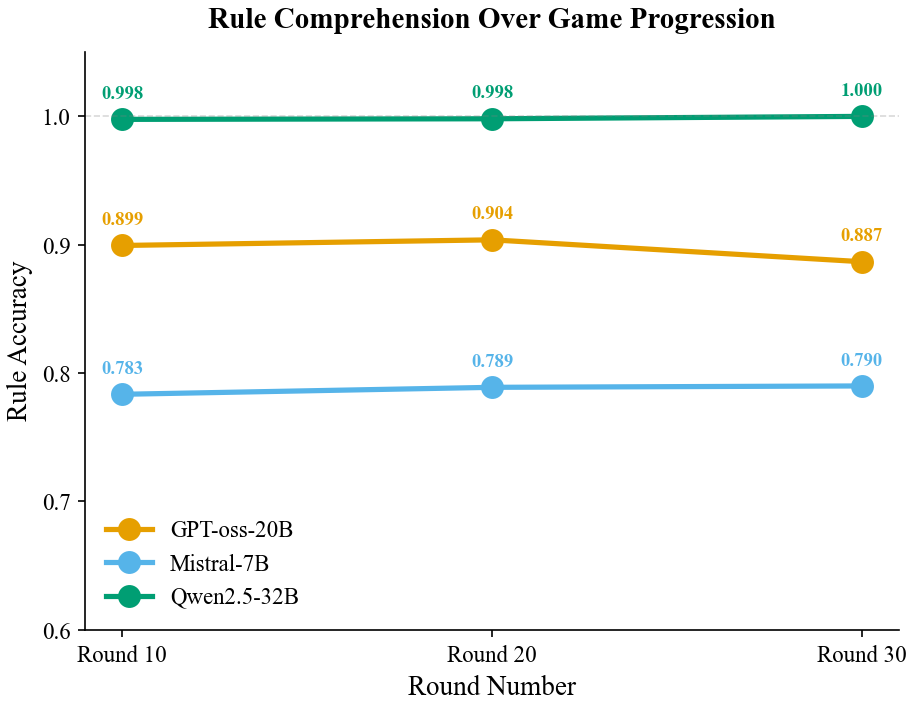

In [17]:
# ── Figure 8e: Does rule comprehension improve over rounds 10 → 20 → 30? ──
fig, ax = plt.subplots(figsize=(7, 5))

for mkey, mname in zip(['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct'], MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    round_acc = sub.groupby('round_number')['is_correct'].mean()
    ax.plot(round_acc.index, round_acc.values, 'o-', color=MODEL_COLORS[mkey],
            label=mname, markersize=10, linewidth=2.5)
    # Annotate values
    for r, v in round_acc.items():
        ax.annotate(f'{v:.3f}', xy=(r, v), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontsize=9,
                    fontweight='bold', color=MODEL_COLORS[mkey])

ax.set_xlabel('Round Number', fontsize=13)
ax.set_ylabel('Rule Accuracy', fontsize=13)
ax.set_title('Rule Comprehension Over Game Progression', fontsize=14, fontweight='bold', pad=12)
ax.set_xticks([10, 20, 30])
ax.set_xticklabels(['Round 10', 'Round 20', 'Round 30'])
ax.set_ylim(0.6, 1.05)
ax.legend(frameon=False)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

plt.savefig(f'{FIGURE_DIR}fig8e_rule_accuracy_over_rounds.pdf')
plt.savefig(f'{FIGURE_DIR}fig8e_rule_accuracy_over_rounds.png')
plt.show()

## Statistical Tests

In [18]:
# ── Statistical tests for rule comprehension ──
print('=' * 70)
print('STATISTICAL ANALYSIS — Rule Comprehension')
print('=' * 70)

# 1. Kruskal-Wallis across models
groups = [df[df['llm_name'] == m]['is_correct'].astype(int) for m in df['llm_name'].unique()]
H, p = stats.kruskal(*groups)
print(f'\n1. Kruskal-Wallis across models: H={H:.2f}, p={p:.2e}')

# 2. Pairwise Mann-Whitney between models
print('\n2. Pairwise Mann-Whitney (Bonferroni-corrected):')
model_names = sorted(df['llm_name'].unique())
n_tests = len(list(combinations(model_names, 2)))
for m1, m2 in combinations(model_names, 2):
    g1 = df[df['llm_name'] == m1]['is_correct'].astype(int)
    g2 = df[df['llm_name'] == m2]['is_correct'].astype(int)
    U, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    p_adj = min(p * n_tests, 1.0)
    sig = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'ns'
    print(f'  {MODEL_LABELS[m1]} vs {MODEL_LABELS[m2]}: U={U:.0f}, p_adj={p_adj:.2e} {sig}')

# 3. Own vs Opponent payoff accuracy (paired test)
own = df[df['question_type'] == 'Own Payoff']['is_correct'].mean()
opp = df[df['question_type'] == 'Opponent Payoff']['is_correct'].mean()
g_own = df[df['question_type'] == 'Own Payoff']['is_correct'].astype(int)
g_opp = df[df['question_type'] == 'Opponent Payoff']['is_correct'].astype(int)
U, p = stats.mannwhitneyu(g_own, g_opp, alternative='two-sided')
print(f'\n3. Own ({own:.3f}) vs Opponent ({opp:.3f}) payoff accuracy:')
print(f'   Mann-Whitney U={U:.0f}, p={p:.2e}')
print(f'   Gap = {own - opp:+.3f} (LLMs better at understanding own payoffs)')

# 4. Effect of noise on rule accuracy
print('\n4. Rule accuracy by noise level:')
for nl in sorted(df['noise_level'].unique()):
    acc = df[df['noise_level'] == nl]['is_correct'].mean()
    n = len(df[df['noise_level'] == nl])
    print(f'   Noise {nl}%: accuracy={acc:.3f} (n={n:,})')

# 5. Kruskal-Wallis across languages
lang_groups = [df[df['language'] == l]['is_correct'].astype(int) for l in df['language'].unique()]
H, p = stats.kruskal(*lang_groups)
print(f'\n5. Kruskal-Wallis across languages: H={H:.2f}, p={p:.2e}')

# 6. Summary table
print('\n6. Complete accuracy breakdown:')
summary = df.groupby(['model', 'noise_label', 'lang_label'])['is_correct'].agg(['mean', 'count'])
summary.columns = ['accuracy', 'n_checks']
print(summary.round(3).to_string())

STATISTICAL ANALYSIS — Rule Comprehension

1. Kruskal-Wallis across models: H=6272.27, p=0.00e+00

2. Pairwise Mann-Whitney (Bonferroni-corrected):
  Mistral-7B vs Qwen2.5-32B: U=279919800, p_adj=0.00e+00 ***
  Mistral-7B vs GPT-oss-20B: U=316203480, p_adj=1.76e-259 ***
  Qwen2.5-32B vs GPT-oss-20B: U=391128480, p_adj=0.00e+00 ***

3. Own (0.989) vs Opponent (0.731) payoff accuracy:
   Mann-Whitney U=316917360, p=0.00e+00
   Gap = +0.258 (LLMs better at understanding own payoffs)

4. Rule accuracy by noise level:
   Noise 0%: accuracy=0.902 (n=26,640)
   Noise 5%: accuracy=0.908 (n=26,640)
   Noise 20%: accuracy=0.872 (n=26,640)

5. Kruskal-Wallis across languages: H=133.66, p=3.97e-27

6. Complete accuracy breakdown:
                                    accuracy  n_checks
model       noise_label lang_label                    
GPT-oss-20B 20% Noise   Arabic         0.694      1480
                        Chinese        0.779      1480
                        English        0.945      14

## Figure 8f — Error Analysis: What Do LLMs Get Wrong?

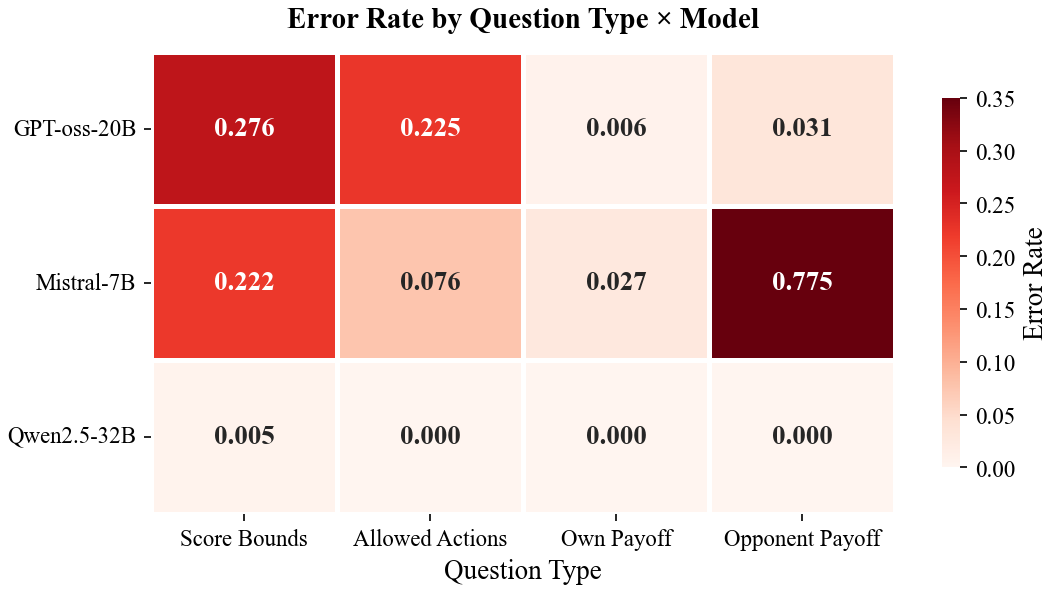


Most common errors for Opponent Payoff questions:
Total opponent payoff errors: 3483

LLM answers vs correct answers (sample):
                llm_name llm_answer correct_answer          question_label
Mistral-7B-Instruct-v0.3         10              0 payoff_check_p1_Coo_Def
Mistral-7B-Instruct-v0.3         10              0 payoff_check_p1_Coo_Def
Mistral-7B-Instruct-v0.3         10              0 payoff_check_p1_Coo_Def
Mistral-7B-Instruct-v0.3         10              0 payoff_check_p1_Coo_Def
Mistral-7B-Instruct-v0.3         10              0 payoff_check_p1_Coo_Def
Mistral-7B-Instruct-v0.3         10              0 payoff_check_p1_Coo_Def
Mistral-7B-Instruct-v0.3         10              0 payoff_check_p1_تعا_خيا
Mistral-7B-Instruct-v0.3         10              0 payoff_check_p1_تعا_خيا
Mistral-7B-Instruct-v0.3         10              0 payoff_check_p1_تعا_خيا
Mistral-7B-Instruct-v0.3         10              0 payoff_check_p1_تعا_خيا
Mistral-7B-Instruct-v0.3         10            

In [19]:
# ── Figure 8f: Error heatmap — question_type × model (only incorrect answers) ──
errors = df[~df['is_correct']].copy()

# Count errors by question type and model
error_counts = errors.groupby(['model', 'question_type']).size().unstack(fill_value=0)
total_counts = df.groupby(['model', 'question_type']).size().unstack(fill_value=0)
error_rate = (error_counts / total_counts).reindex(index=MODEL_ORDER, columns=q_types)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(error_rate, annot=True, fmt='.3f', cmap='Reds', vmin=0, vmax=0.35,
            linewidths=1.5, linecolor='white', cbar_kws={'label': 'Error Rate', 'shrink': 0.8},
            annot_kws={'fontsize': 13, 'fontweight': 'bold'}, ax=ax)
ax.set_title('Error Rate by Question Type × Model', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Question Type', fontsize=13)
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.savefig(f'{FIGURE_DIR}fig8f_rule_error_heatmap.pdf')
plt.savefig(f'{FIGURE_DIR}fig8f_rule_error_heatmap.png')
plt.show()

# Analyze common wrong answers for opponent payoff
print('\nMost common errors for Opponent Payoff questions:')
opp_errors = errors[errors['question_type'] == 'Opponent Payoff']
print(f'Total opponent payoff errors: {len(opp_errors)}')
print('\nLLM answers vs correct answers (sample):')
sample = opp_errors[['llm_name', 'llm_answer', 'correct_answer', 'question_label']].head(15)
print(sample.to_string(index=False))

## Summary Table

In [20]:
# ── Publication-ready summary table ──
print('=' * 70)
print('TABLE: Rule Comprehension Summary')
print('=' * 70)

# Overall accuracy and 95% CI per model
print('\nModel | Overall Accuracy | 95% CI | Score Bounds | Allowed Actions | Own Payoff | Opponent Payoff')
print('-' * 100)
for model in MODEL_ORDER:
    sub = df[df['model'] == model]
    acc = sub['is_correct'].mean()
    n = len(sub)
    se = np.sqrt(acc * (1 - acc) / n)
    ci_lo = acc - 1.96 * se
    ci_hi = acc + 1.96 * se
    
    sb = sub[sub['question_type'] == 'Score Bounds']['is_correct'].mean()
    aa = sub[sub['question_type'] == 'Allowed Actions']['is_correct'].mean()
    op = sub[sub['question_type'] == 'Own Payoff']['is_correct'].mean()
    opp = sub[sub['question_type'] == 'Opponent Payoff']['is_correct'].mean()
    
    print(f'{model:15s} | {acc:.3f}            | [{ci_lo:.3f}, {ci_hi:.3f}] | '
          f'{sb:.3f}        | {aa:.3f}           | {op:.3f}     | {opp:.3f}')

print('\nKey Finding: LLMs understand their OWN payoffs significantly better than OPPONENT payoffs.')
print('This "perspective gap" suggests limited theory-of-mind in game-theoretic reasoning.')

TABLE: Rule Comprehension Summary

Model | Overall Accuracy | 95% CI | Score Bounds | Allowed Actions | Own Payoff | Opponent Payoff
----------------------------------------------------------------------------------------------------
GPT-oss-20B     | 0.896            | [0.893, 0.900] | 0.724        | 0.775           | 0.994     | 0.969
Mistral-7B      | 0.787            | [0.782, 0.792] | 0.778        | 0.924           | 0.973     | 0.225
Qwen2.5-32B     | 0.999            | [0.998, 0.999] | 0.995        | 1.000           | 1.000     | 1.000

Key Finding: LLMs understand their OWN payoffs significantly better than OPPONENT payoffs.
This "perspective gap" suggests limited theory-of-mind in game-theoretic reasoning.
